In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [49]:
data_df = pd.read_csv("/content/drive/MyDrive/Machine Learning/Supervised Learning/Loan_approval_task/loan_approval_data.csv")

data_df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [50]:
data_df.shape

(1000, 20)

In [51]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [52]:
data_df.isnull().sum()

,0
Applicant_ID,50
Applicant_Income,50
Coapplicant_Income,50
Employment_Status,50
Age,50
Marital_Status,50
Dependents,50
Credit_Score,50
Existing_Loans,50
DTI_Ratio,50


In [53]:
data_df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# handle a missing values

In [54]:
categorical_cols = data_df.select_dtypes(include=['object']).columns
numerical_cols = data_df.select_dtypes(include=['float64']).columns

In [55]:
print(categorical_cols)
print(numerical_cols)

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')
Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')


In [56]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
data_df[numerical_cols] = num_imputer.fit_transform(data_df[numerical_cols])

data_df.isnull().sum()

,0
Applicant_ID,0
Applicant_Income,0
Coapplicant_Income,0
Employment_Status,50
Age,0
Marital_Status,50
Dependents,0
Credit_Score,0
Existing_Loans,0
DTI_Ratio,0


In [57]:
cat_imputer = SimpleImputer(strategy="most_frequent")
data_df[categorical_cols] = cat_imputer.fit_transform(data_df[categorical_cols])

data_df.isnull().sum()

,0
Applicant_ID,0
Applicant_Income,0
Coapplicant_Income,0
Employment_Status,0
Age,0
Marital_Status,0
Dependents,0
Credit_Score,0
Existing_Loans,0
DTI_Ratio,0


## EDA - exploratory data analysis

In [58]:
# how the balance classes are ?
classes_count = data_df['Loan_Approved'].value_counts()
print(classes_count)

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64


Text(0.5, 1.0, 'Is Loan approved or not ?')

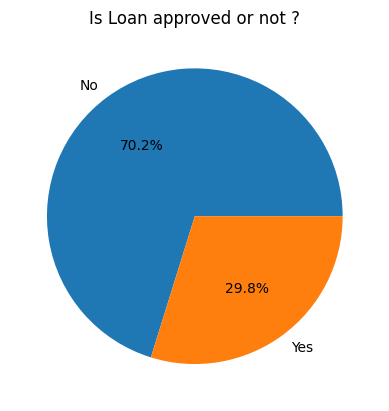

In [59]:
plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is Loan approved or not ?")

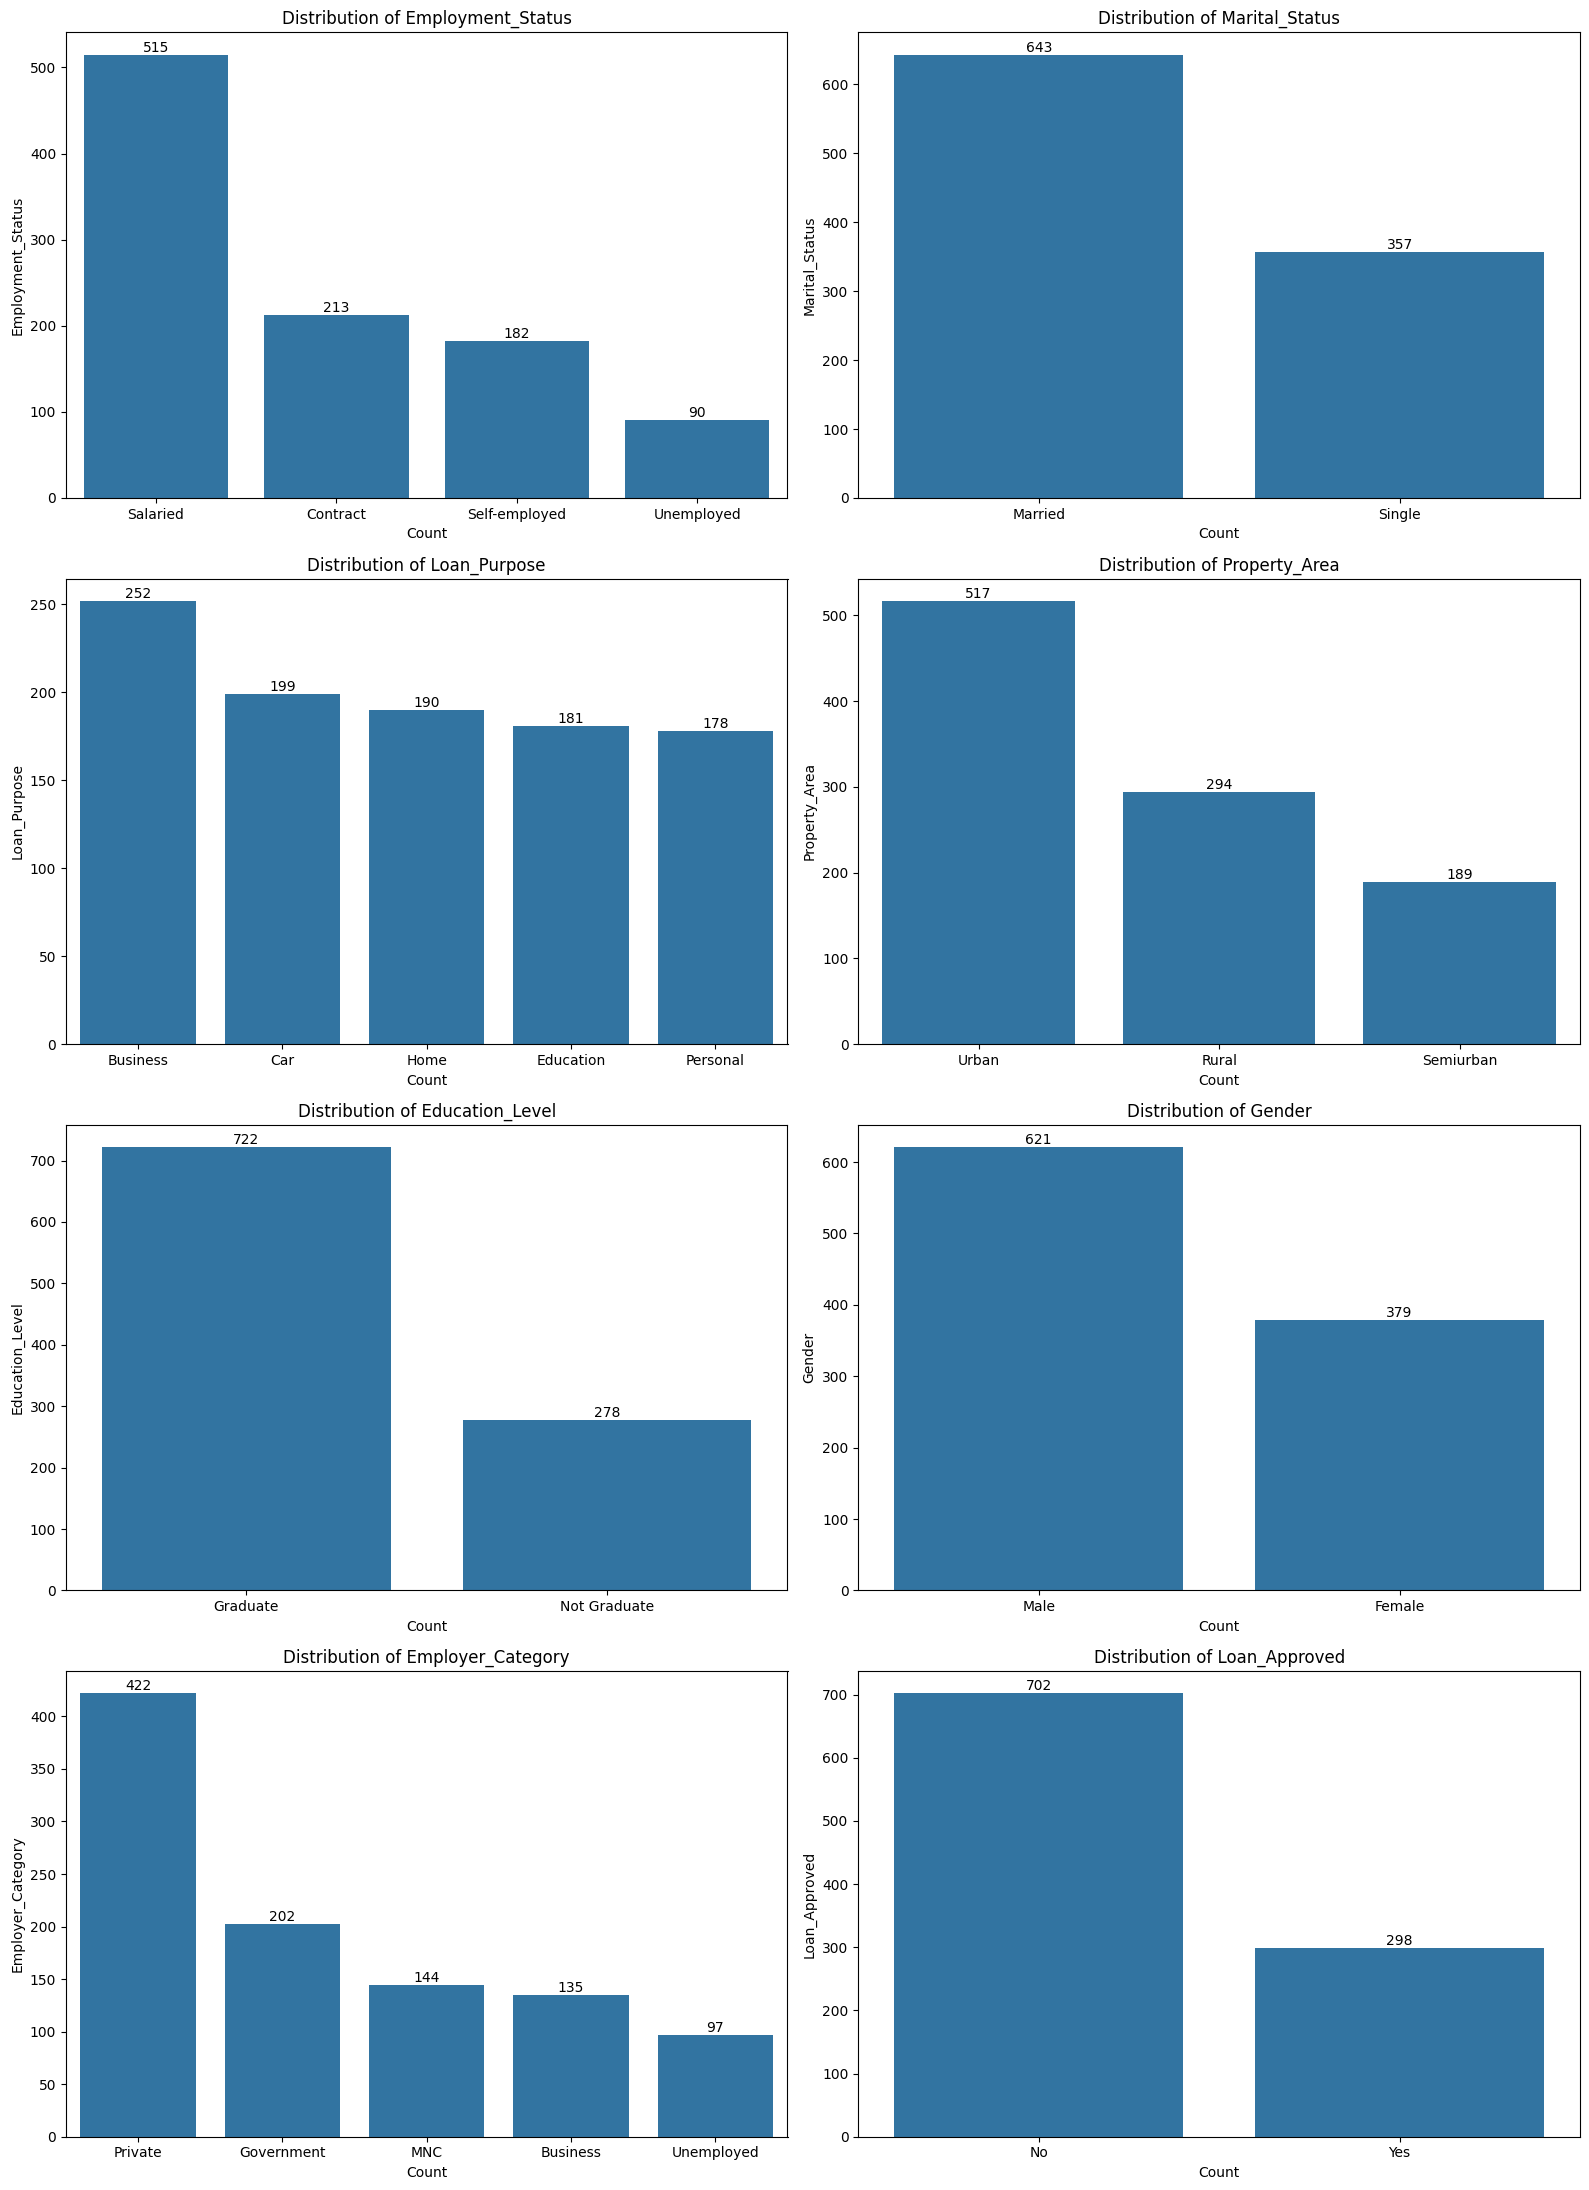

In [60]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 22)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    counts = data_df[col].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel(col)

    axes[i].bar_label(axes[i].containers[0])

plt.tight_layout()
plt.show()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

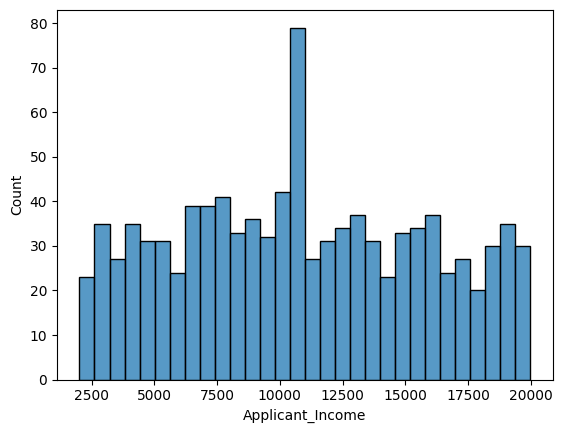

In [61]:
# analyze income

sns.histplot(
    data=data_df,
    x="Applicant_Income",
    bins=30
)

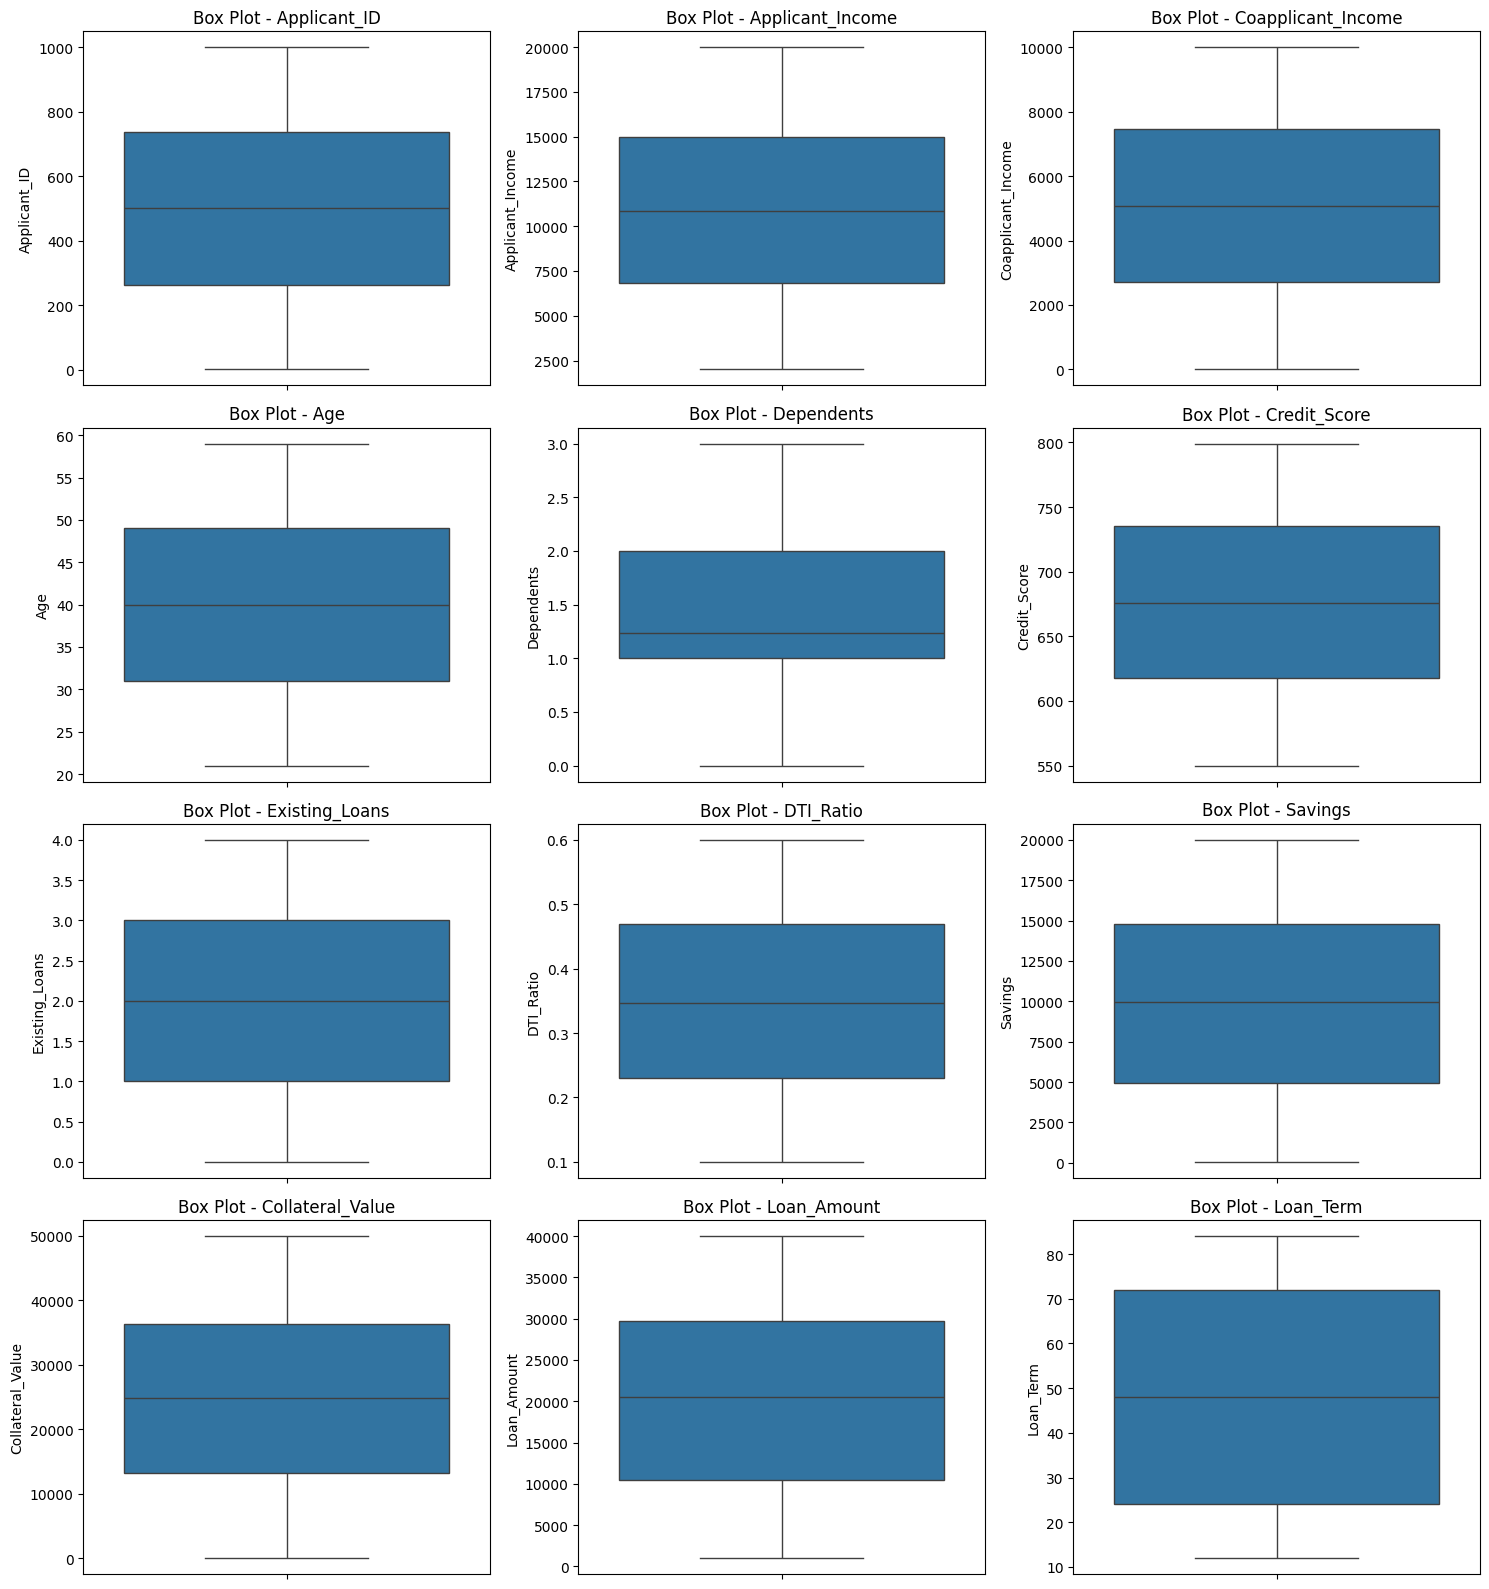

In [62]:
# check outliers in numerical columns
fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(15, 16)
)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        y=data_df[col],
        ax=axes[i]
    )

    axes[i].set_title(f"Box Plot - {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

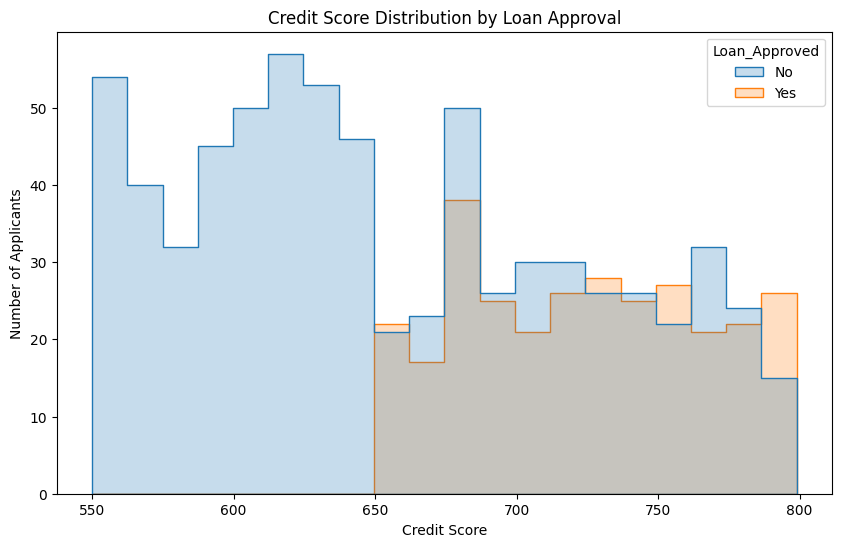

In [63]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data_df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    element="step",
)

plt.title("Credit Score Distribution by Loan Approval")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")

plt.show()

In [64]:
data_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

In [65]:
# remove column(Feature)
data_df = data_df.drop("Applicant_ID",axis=1)


In [66]:
data_df.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age',
       'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans',
       'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term',
       'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender',
       'Employer_Category', 'Loan_Approved'],
      dtype='object')

# Encoding (Feature Encoding)

In [67]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [68]:
nominal_cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"] # for OneHotEncoding
ordinal_cols = ["Education_Level","Loan_Approved" ]  #for LabelEncoding

In [69]:
le = LabelEncoder()

for col in ordinal_cols:
  data_df[col] = le.fit_transform(data_df[col])

In [70]:
data_df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [71]:
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded_array = ohe.fit_transform(data_df[nominal_cols]) #here return nd array

encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(nominal_cols), index=data_df.index)

data_df = data_df.drop(nominal_cols, axis=1) # drop a previous columns

data_df = pd.concat([data_df, encoded_df], axis=1) # concatination old dataset to new dataframes


In [72]:
data_df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [73]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# CoRelation Heatmap

<Axes: >

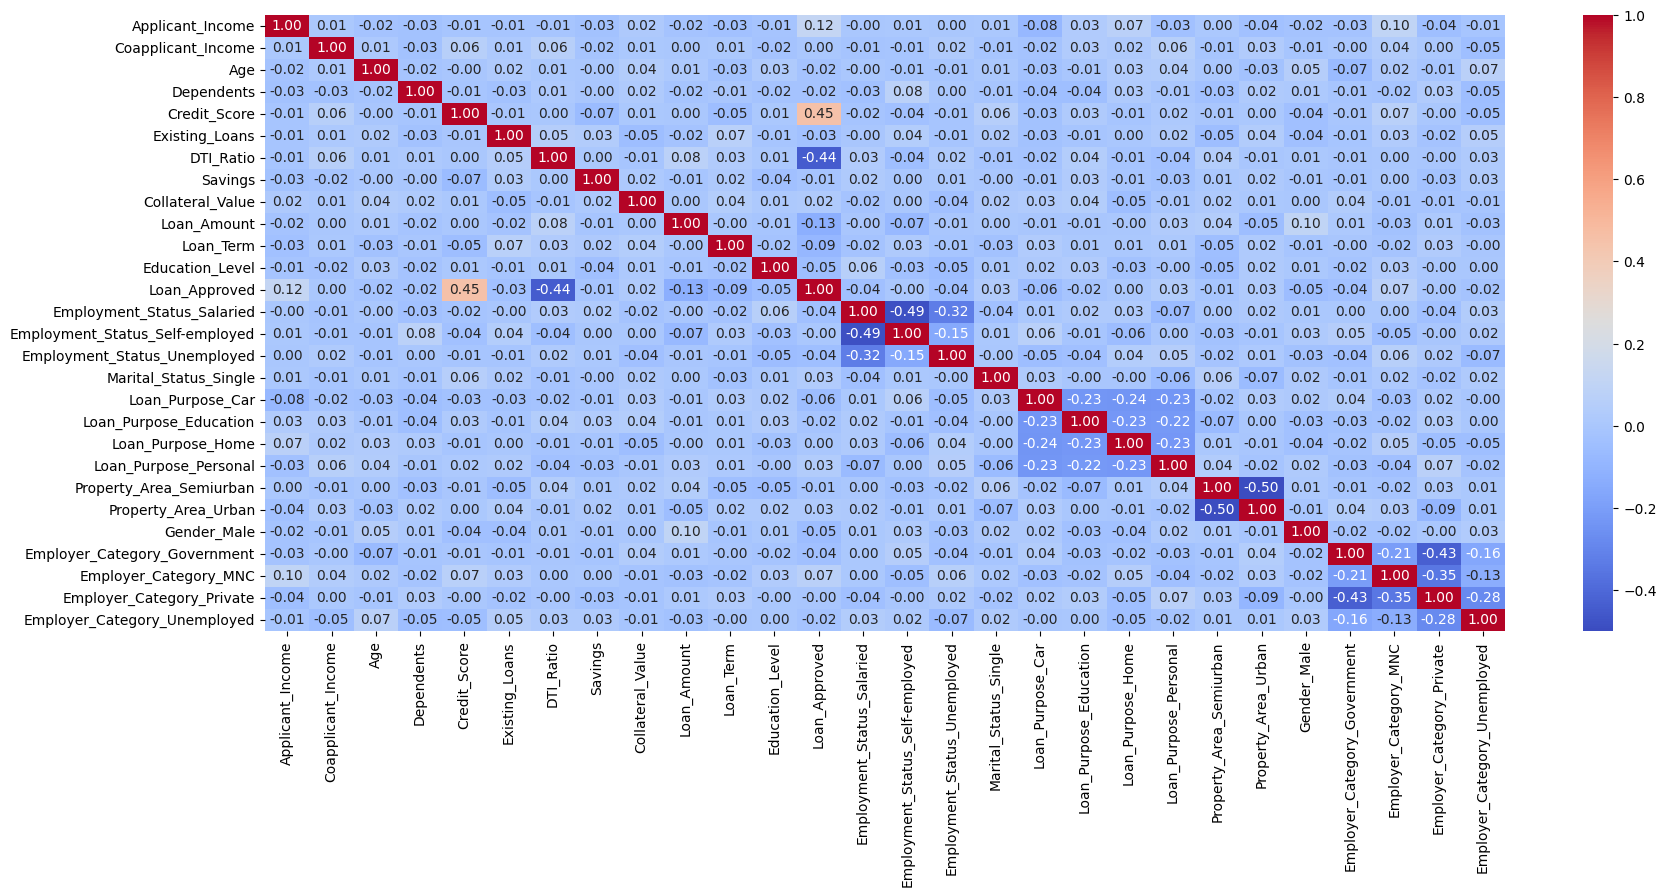

In [74]:
num_cols = data_df.select_dtypes(include="number")

corr_matrix = num_cols.corr()

# print(corr_matrix)
plt.figure(figsize=(20, 8))
sns.heatmap(
  corr_matrix,
  annot= True,
  fmt=".2f",
  cmap="coolwarm"
)

In [75]:
num_cols.corr()["Loan_Approved"].sort_values(ascending = False)

,Loan_Approved
Loan_Approved,1.000000
Credit_Score,0.451175
Applicant_Income,0.119796
Employer_Category_MNC,0.069049
Loan_Purpose_Personal,0.034043
Marital_Status_Single,0.030182
Property_Area_Urban,0.025963
Collateral_Value,0.021868
Coapplicant_Income,0.004230
Loan_Purpose_Home,0.002118


# Train + Test Split  && Feature Scalling

In [76]:
X = data_df.drop("Loan_Approved",axis=1)
y= data_df["Loan_Approved"]

In [77]:
X.shape

(1000, 27)

In [78]:
y.shape

(1000,)

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(800, 27)
(200, 27)


In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train && Evaluate Model

In [81]:
#  logistic regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

In [82]:
# KNN classification
from sklearn.neighbors import KNeighborsClassifier

knn_classifier = KNeighborsClassifier(n_neighbors=7)

knn_classifier.fit(X_train, y_train)

knn_pred = knn_classifier.predict(X_test)

In [83]:
# Naive Bayes classification

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [84]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

print("Logistic Regression Metrics:")
print("Precision : ",precision_score(y_test, log_pred))
print("Recall : ",recall_score(y_test, log_pred))
print("Accuracy : ",accuracy_score(y_test, log_pred))
print("CM :", confusion_matrix(y_test, log_pred))

print("\n-----------------------------------------------------------\n")
print("KNN Classification Metrics:")
print("Precision : ",precision_score(y_test, knn_pred))
print("Recall : ",recall_score(y_test, knn_pred))
print("Accuracy : ",accuracy_score(y_test, knn_pred))
print("CM :", confusion_matrix(y_test, knn_pred))

print("\n-----------------------------------------------------------\n")
print("Naive Bayes Classification Metrics:")
print("Precision : ",precision_score(y_test, nb_pred))
print("Recall : ",recall_score(y_test, nb_pred))
print("Accuracy : ",accuracy_score(y_test, nb_pred))
print("CM :", confusion_matrix(y_test, nb_pred))

Logistic Regression Metrics:
Precision :  0.7833333333333333
Recall :  0.7704918032786885
Accuracy :  0.865
CM : [[126  13]
 [ 14  47]]

-----------------------------------------------------------

KNN Classification Metrics:
Precision :  0.6086956521739131
Recall :  0.45901639344262296
Accuracy :  0.745
CM : [[121  18]
 [ 33  28]]

-----------------------------------------------------------

Naive Bayes Classification Metrics:
Precision :  0.8035714285714286
Recall :  0.7377049180327869
Accuracy :  0.865
CM : [[128  11]
 [ 16  45]]


# Feature Engineering :

In [90]:
# add and transform feature

# data_df['DTI_Ratio_sq'] = data_df['DTI_Ratio'] ** 2
data_df['Credit_Score_sq'] = data_df['Credit_Score'] ** 2

X= data_df.drop(["Loan_Approved","Credit_Score"],axis=1)
y= data_df["Loan_Approved"]

# train & test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---> Train && Evaluate Model

#  logistic regression
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)


# KNN classification
knn_classifier = KNeighborsClassifier(n_neighbors=7)

knn_classifier.fit(X_train, y_train)

knn_pred = knn_classifier.predict(X_test)


# Naive Bayes classification
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [91]:
print("Logistic Regression Metrics:")
print("Precision : ",precision_score(y_test, log_pred))
print("Recall : ",recall_score(y_test, log_pred))
print("Accuracy : ",accuracy_score(y_test, log_pred))
print("CM :", confusion_matrix(y_test, log_pred))

print("\n-----------------------------------------------------------\n")
print("KNN Classification Metrics:")
print("Precision : ",precision_score(y_test, knn_pred))
print("Recall : ",recall_score(y_test, knn_pred))
print("Accuracy : ",accuracy_score(y_test, knn_pred))
print("CM :", confusion_matrix(y_test, knn_pred))

print("\n-----------------------------------------------------------\n")
print("Naive Bayes Classification Metrics:")
print("Precision : ",precision_score(y_test, nb_pred))
print("Recall : ",recall_score(y_test, nb_pred))
print("Accuracy : ",accuracy_score(y_test, nb_pred))
print("CM :", confusion_matrix(y_test, nb_pred))

Logistic Regression Metrics:
Precision :  0.7538461538461538
Recall :  0.8032786885245902
Accuracy :  0.86
CM : [[123  16]
 [ 12  49]]

-----------------------------------------------------------

KNN Classification Metrics:
Precision :  0.6595744680851063
Recall :  0.5081967213114754
Accuracy :  0.77
CM : [[123  16]
 [ 30  31]]

-----------------------------------------------------------

Naive Bayes Classification Metrics:
Precision :  0.7058823529411765
Recall :  0.7868852459016393
Accuracy :  0.835
CM : [[119  20]
 [ 13  48]]


In [87]:
numeric_cols = data_df.select_dtypes(include="number").columns

skewness = data_df[numeric_cols].skew().sort_values(ascending=False)

print(skewness)

Employment_Status_Unemployed       2.869618
Employer_Category_Unemployed       2.727454
Employer_Category_MNC              2.031019
Loan_Purpose_Personal              1.686134
Loan_Purpose_Education             1.659555
Employment_Status_Self-employed    1.650810
Property_Area_Semiurban            1.591114
Loan_Purpose_Home                  1.582795
Loan_Purpose_Car                   1.510101
Employer_Category_Government       1.486693
Education_Level                    0.992531
Loan_Approved                      0.884620
Marital_Status_Single              0.597831
DTI_Ratio_sq                       0.561213
Employer_Category_Private          0.316342
Existing_Loans                     0.083230
Credit_Score_sq                    0.078898
Applicant_Income                   0.074384
Dependents                         0.068112
Collateral_Value                   0.065935
DTI_Ratio                          0.057100
Savings                            0.010815
Loan_Term                       